# D0027 / D0030 / D0033 / D0036 — targeted stress test

**No new aircraft combinations.** This notebook audits only the four candidates that passed all three original polars. Restart the kernel and run all cells. The original 324-case table is retained as historical evidence.

The question: does the approximately +19 N pessimistic-case margin survive fixed non-wing drag area and total installation losses of 15–25%? The five-second Mach 1.01 hold remains an independent requirement.

In [1]:
from pathlib import Path
import sys, os
from io import BytesIO
ROOT=Path.cwd()
if not (ROOT/'gypaetus').is_dir(): ROOT=ROOT.parent
assert (ROOT/'gypaetus').is_dir()
sys.path.insert(0,str(ROOT))
os.environ.setdefault('MPLCONFIGDIR',str(ROOT/'.mplconfig'))
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display
from gypaetus.stress import CANDIDATES, run_stress
from gypaetus.stress_report import plot_evidence, write_report
OUT=ROOT/'results'/'stress'
display(pd.DataFrame([{'design_id':k,'empty_mass_kg':v[0],'fuel_kg':v[1],
    'total_mass_kg':sum(v),'mass_loading_kg_m2':sum(v)/0.08} for k,v in CANDIDATES.items()]))

,design_id,empty_mass_kg,fuel_kg,total_mass_kg,mass_loading_kg_m2
0,D0027,18.0,1.0,19.0,237.5
1,D0030,21.0,1.0,22.0,275.0
2,D0033,18.0,3.0,21.0,262.5
3,D0036,21.0,3.0,24.0,300.0


## Explicit assumptions

- S stays **0.08 m²**, altitude **6,000 m**, bench rating **600 N**, with level flight.
- Retain the optimistic, baseline and pessimistic polar families.
- Total installation factors are **0.85, 0.80, 0.75**. The original 15% loss is not applied twice. Altitude/Mach lapse remains separate. At fixed throttle, fuel flow does not decrease with installation loss.
- Fixed-body model: allocate **50% of parasite and wave drag at the original 0.12 m² reference** to body/inlet/external-engine geometry; retain that component's Cd×A and Reynolds length. The rest scales with the wing. No measured frontal area or drag split exists.
- At the anchor geometry, drag equals the old polar. The correction is a change in the assumed physical drag scaling, not merely changing units. Induced and trim drag remain separate.
- Also calculate the smaller body fraction/additional drag area that erases the force margin. These are sensitivity thresholds, not measured geometry.
- Keep the **Mach 1.01, five-second hold**. A gate pass never automatically sets endurance_pass.

In [2]:
results=run_stress(OUT)
assert set(results.design_id)==set(CANDIDATES)
assert len(results)==72
summary=results.groupby(['drag_case','drag_area_model','total_installation_loss_pct']).agg(
    existing_candidates=('design_id','nunique'), gate_passes=('gate_pass','sum'), hold_passes=('endurance_pass','sum'))
display(summary)

existing_candidates  \
drag_case   drag_area_model      total_installation_loss_pct                        
baseline    fixed_body_50pct     15                                             4   
                                 20                                             4   
                                 25                                             4   
            original_wing_scaled 15                                             4   
                                 20                                             4   
                                 25                                             4   
optimistic  fixed_body_50pct     15                                             4   
                                 20                                             4   
                                 25                                             4   
            original_wing_scaled 15                                             4   
                                 20                                             4   
                                 25                                             4   
pessimistic fixed_body_50pct     15                                             4   
                                 20                                             4   
                                 25                                             4   
            original_wing_scaled 15                                             4   
                                 20                                             4   
                                 25                                             4   

                                                              gate_passes  \
drag_case   drag_area_model      total_installation_loss_pct                
baseline    fixed_body_50pct     15                                     4   
                                 20                                     4   
                                 25                                     4   
            original_wing_scaled 15                                     4   
                                 20                                     4   
                                 25                                     4   
optimistic  fixed_body_50pct     15                                     4   
                                 20                                     4   
                                 25                                     4   
            original_wing_scaled 15                                     4   
                                 20                                     4   
                                 25                                     4   
pessimistic fixed_body_50pct     15                                     0   
                                 20                                     0   
                                 25                                     0   
            original_wing_scaled 15                                     4   
                                 20                                     4   
                                 25                                     0   

                                                              hold_passes  
drag_case   drag_area_model      total_installation_loss_pct               
baseline    fixed_body_50pct     15                                     4  
                                 20                                     4  
                                 25                                     4  
            original_wing_scaled 15                                     4  
                                 20                                     4  
                                 25                                     4  
optimistic  fixed_body_50pct     15                                     4  
                                 20                                     4  
                                 25                         

## Gate versus full-interval force margin

The solver stops or times out before flying through a negative acceleration margin. Therefore its failed trajectory may have a minimum near zero. To assess the full Mach 0.8–1 interval, calculate T−D separately at the same entry mass and at empty mass. The empty-mass case is a generous lower-drag mathematical bound with thrust available, **not a fuel-free flight**.

Keep these bounds separate from the integrated trajectory minimum. The table below does so.

,design_id,drag_area_model,total_installation_loss_pct,min_excess_thrust_n,full_gate_entry_min_excess_n,full_gate_dry_bound_min_excess_n,gate_pass,endurance_pass,final_mach,termination,endurance_termination,level_hold_attempted
4,D0027,original_wing_scaled,15,19.790933,19.751801,19.942180,True,True,1.000000,target_reached,hold_complete,True
5,D0027,fixed_body_50pct,15,0.012385,-39.141937,-38.951558,False,False,0.965623,fuel_exhausted,gate_failed,False
10,D0027,original_wing_scaled,20,3.968360,3.902454,4.092833,True,False,1.000000,target_reached,fuel_exhausted,False
11,D0027,fixed_body_50pct,20,0.012227,-54.991283,-54.800905,False,False,0.953137,fuel_exhausted,gate_failed,False
16,D0027,original_wing_scaled,25,0.018003,-11.946892,-11.756513,False,False,0.986132,fuel_exhausted,gate_failed,False
17,D0027,fixed_body_50pct,25,0.012296,-70.840630,-70.650251,False,False,0.940980,fuel_exhausted,gate_failed,False
22,D0030,original_wing_scaled,15,19.172087,19.118920,19.340171,True,True,1.000000,target_reached,hold_complete,True
23,D0030,fixed_body_50pct,15,0.017063,-39.774818,-39.553567,False,False,0.965107,fuel_exhausted,gate_failed,False
28,D0030,original_wing_scaled,20,3.361999,3.269574,3.490825,True,False,1.000000,target_reached,fuel_exhausted,False
29,D0030,fixed_body_50pct,20,0.016788,-55.624164,-55.402913,False,False,0.952629,fuel_exhausted,gate_failed,False


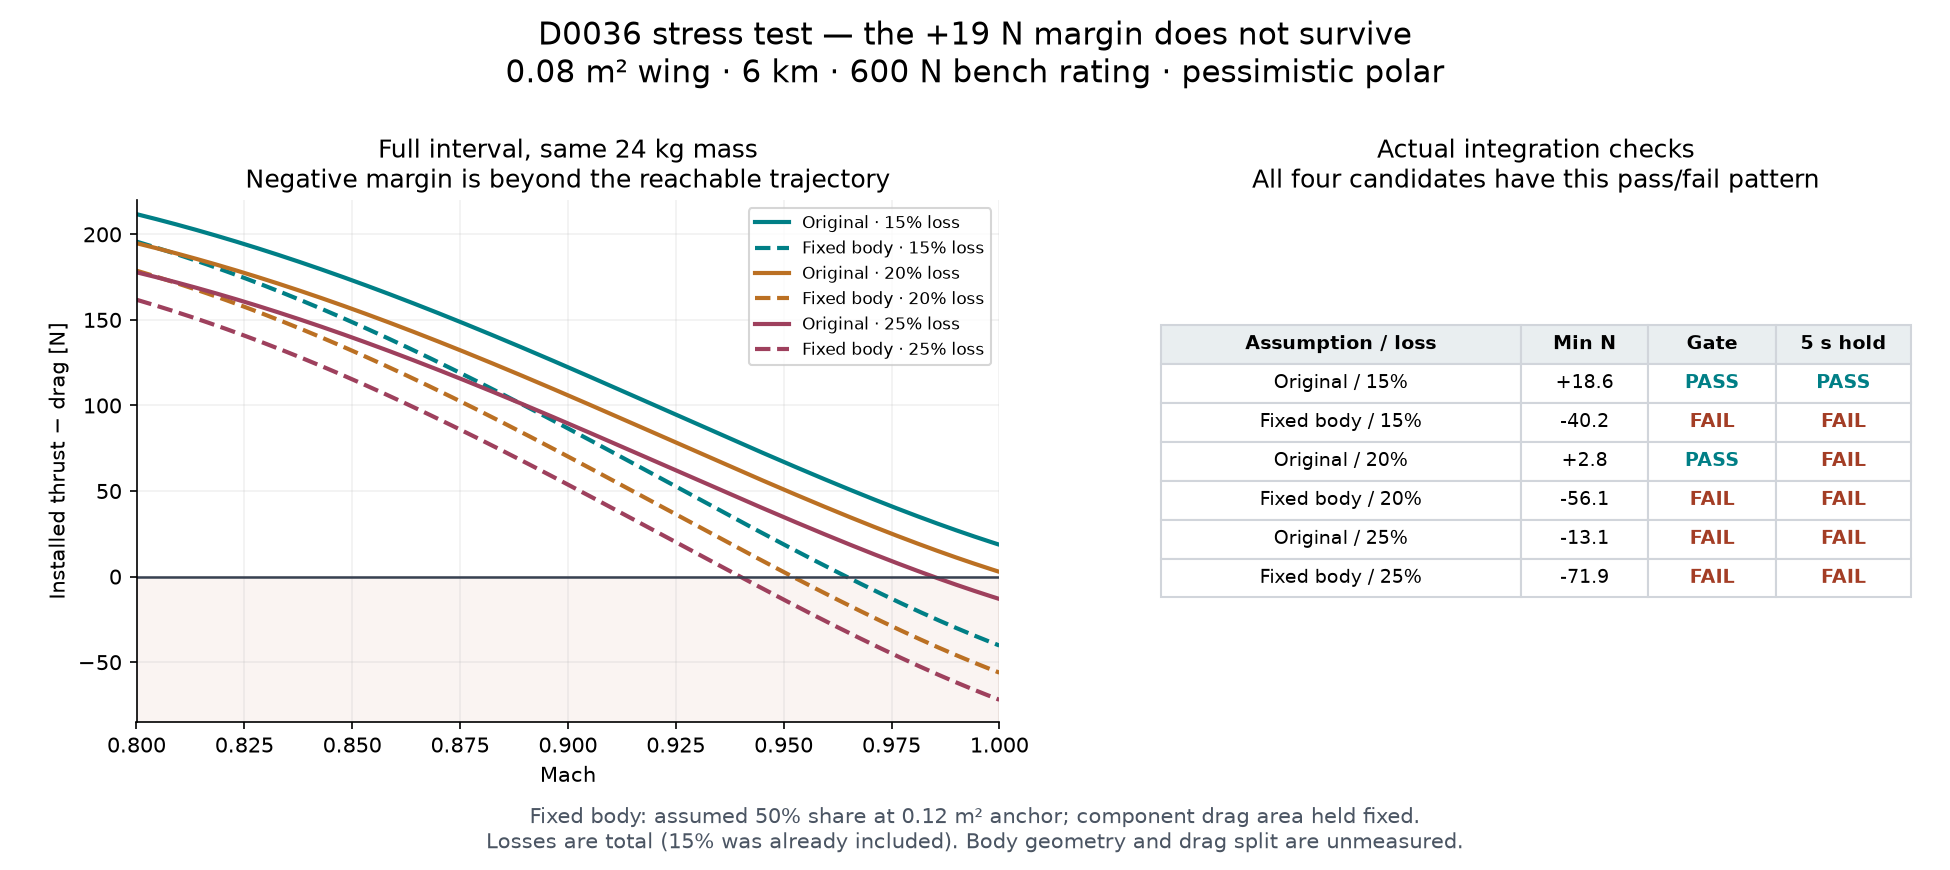

In [3]:
pessimistic=results[results.drag_case=='pessimistic']
columns=['design_id','drag_area_model','total_installation_loss_pct','min_excess_thrust_n',
    'full_gate_entry_min_excess_n','full_gate_dry_bound_min_excess_n','gate_pass','endurance_pass',
    'final_mach','termination','endurance_termination','level_hold_attempted']
display(pessimistic[columns])
fig=plot_evidence(OUT)
image=BytesIO()
fig.savefig(image,format='png',dpi=150)
display(Image(data=image.getvalue()))
plt.close(fig)

## Break-even drag allowance

Positive allowances show how little additional equivalent drag area or wing-reference CD erases the force margin. A negative allowance means the original polar already lacks sufficient thrust. The critical body fraction applies only to the stated 0.12 m² anchor model. These are force-only limits; time, fuel and hold checks still apply.

In [4]:
limits=pd.read_csv(OUT/'break_even_limits.csv')
display(limits[(limits.design_id=='D0036') & (limits.drag_case=='pessimistic')])
display(pessimistic[(pessimistic.drag_area_model=='original_wing_scaled') &
    (pessimistic.total_installation_loss_pct==20)][['design_id','gate_pass','endurance_pass',
     'time_to_mach_1_s','endurance_termination','final_fuel_kg','level_hold_attempted']])

,design_id,drag_case,total_installation_loss_pct,audit_basis,critical_fixed_body_fraction,controlling_mach,permitted_extra_constant_drag_area_m2,permitted_extra_wing_cd
58,D0036,pessimistic,15,entry_mass,0.158213,1.0,0.000564,0.007048
59,D0036,pessimistic,15,dry_mass_lower_drag_bound,0.164111,1.0,0.000585,0.007310
64,D0036,pessimistic,20,entry_mass,0.023654,1.0,0.000084,0.001054
65,D0036,pessimistic,20,dry_mass_lower_drag_bound,0.029552,1.0,0.000105,0.001316
70,D0036,pessimistic,25,entry_mass,-0.110904,1.0,-0.000395,-0.004940
71,D0036,pessimistic,25,dry_mass_lower_drag_bound,-0.105007,1.0,-0.000374,-0.004678


,design_id,gate_pass,endurance_pass,time_to_mach_1_s,endurance_termination,final_fuel_kg,level_hold_attempted
10,D0027,True,False,24.835324,fuel_exhausted,0.000000,False
28,D0030,True,False,30.101857,fuel_exhausted,0.000000,False
46,D0033,True,False,28.259188,time_limit,1.370008,False
64,D0036,True,False,34.127497,time_limit,1.369182,False


## Updated gate answer

The conclusion below is generated from the targeted outputs. Baseline and optimistic survival must be reported alongside the loss of pessimistic-case robustness. Whether this high-altitude dart is a buildable airplane remains a separate gate.

In [5]:
report=write_report(OUT)
display(Markdown(report.split('## Scope')[0]))
print('Full assumptions, force evidence and hold outcomes:', OUT/'REPORT.md')

# Four-candidate stress test — no design-grid expansion

**Conservative robustness verdict: feasible only on the assumed polars, not after installation and reference-area consistency.**

This verdict concerns the loss of the original all-three-polar pass: the pessimistic case fails the fixed-body sensitivity at every installation loss tested. The optimistic and baseline cases still pass both gate and hold for all four candidates. This is not proof of universal infeasibility, nor a geometry-calibrated drag prediction.



Full assumptions, force evidence and hold outcomes: /Users/jeremiahmaysmei/Documents/ChatGPT/Gypaetus/results/stress/REPORT.md
